# Machine Learning Pipeline

Now that we have experience preparing data for input to machine learning libraries, the next step will be to train, tune, and test a model.  You will perform all three of these steps in this hands-on activity.

The assignment consists of the following steps:

1. Load two datasets and prepare their representations and labels for model input. 
2. Split the data into training and testing.
3. Select a model, and identify the parameters to tune.
4. Tune the model.
5. Evaluate the model's performance.

In [5]:
import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

from netml.pparser.parser import PCAP
from netml.utils.tool import dump_data, load_data

import pandas as pd

## Convert the Packet Capture Into Flows

1. Load the two packet captures for HTTP requests and Log4j scan, 
2. convert them into traffic flows, 
3. generate features from the flow,  
4. label the traffic,
5. normalize your labeled features into a 2D matrix

In [6]:
import numpy as np

http_pcap = PCAP("data/http.pcap")
log4j_pcap = PCAP("data/log4j.pcap")

http_pcap.pcap2flows()
log4j_pcap.pcap2flows()

print(f"http flows:  {len(http_pcap.flows)}")
print(f"log4j flows: {len(log4j_pcap.flows)}")

# STATS gives a fixed-length feature vector per flow (10 summary stats),
# so the two matrices come out with the same number of columns already.
http_pcap.flow2features("STATS", fft=False, header=False)
log4j_pcap.flow2features("STATS", fft=False, header=False)

X_http = http_pcap.features
X_log4j = log4j_pcap.features

print(X_http.shape, X_log4j.shape)

y_http = np.zeros(len(X_http))     # non-attack
y_log4j = np.ones(len(X_log4j))    # attack

# Defensive: if you swap in a feature type (e.g. IAT/SIZE) whose width depends
# on q_interval padding, the two matrices may not line up — trim to the
# smaller width before stacking.
n_cols = min(X_http.shape[1], X_log4j.shape[1])
X_http = X_http[:, :n_cols]
X_log4j = X_log4j[:, :n_cols]

X = np.vstack([X_http, X_log4j])
y = np.concatenate([y_http, y_log4j])

print(X.shape, y.shape)



http flows:  291
log4j flows: 4795
(291, 12) (4795, 12)
(5086, 12) (5086,)


## Evaluating a Machine Learning Model

The goal of supervised learning is to train a model that takes examples and predicts labels for these examples that are as close as possible to the actual labels. For instance, in this example above, a model might take features from a traffic trace and predict whether the traffic constitutes regular web traffic or a scan.

How do you measure whether the model is succeeding if you don't know the true labels for new observations? The way to solve this problem is to test the performance of the trained algorithm on additional data that it has never seen, but for which you already know the correct labels. 

This requires that you train the algorithm using only a portion of the entire labeled dataset (the **training set**) and withold the rest of the labeled data (the **test set**) for testing how well the model generalizes to new information. 

To evaluate the model, we will need to split the data into train and test sets.

### Split into Training and Test Sets

Split your data into a training and test set using scikit-learn. A common split is to train on 80% of your data, while withholding 20% of the data. 

In [ ]:
from sklearn.model_selection import train_test_split

# stratify=y keeps the attack/non-attack ratio consistent across both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"train: {X_train.shape}, test: {X_test.shape}")

train: (4068, 12), test: (1018, 12)
train: (4068,), test: (1018,)


### Training Your Model

Now that you have split your data into training and testing sets, you are ready to train and evaluate a model. 

Import a machine learning model of your choice, use your training set to train the model, and use the test set to evaluate it. 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

clf = RandomForestClassifier(class_weight="balanced", random_state=42)
clf.fit(X_train, y_train)




RandomForestClassifier(class_weight='balanced', random_state=42)

In [11]:
y_pred = clf.predict(X_test)

print(f"accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=["non-attack", "attack"]))

accuracy: 0.9941
              precision    recall  f1-score   support

  non-attack       1.00      0.90      0.95        58
      attack       0.99      1.00      1.00       960

    accuracy                           0.99      1018
   macro avg       1.00      0.95      0.97      1018
weighted avg       0.99      0.99      0.99      1018



### Test Your Trained Model

You can now evaluate how well your trained model works.  There are several valuable ways to visualize your results. You might use techniques such as a confusion matrix, or a receiver operating characteristic (ROC) curve. Below we will gain some experience plotting both of those.  This [documentation](https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_display_object_visualization.html) may help you with plotting these results.

#### Confusion Matrix 

A confusion matrix is a one way to understand errors of different types. We can see a lot of examples off diagonal, suggesting a fair number of incorrect answers.

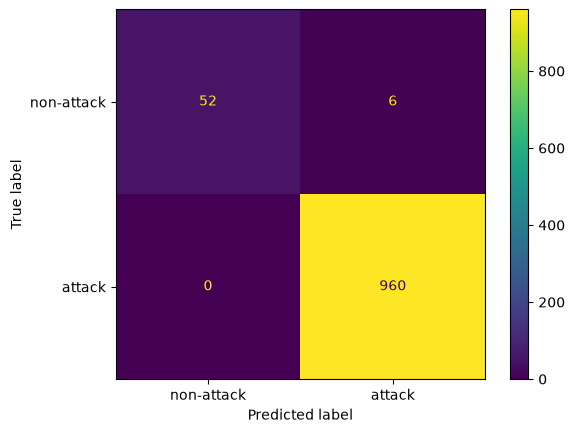

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["non-attack", "attack"]
)
plt.show()

#### Receiver Operating Characteristic

Some models can output different classes based on a threshold that is set for the decision. 

#### Area Under the Curve (AUC)

From the ROC above, you can also compute a metric called the area under the curve (AUC). Visually, this is the area under the curve that you just plotted. You could see, intuitively, that the "best" performance should yield an AUC of 1, and the worst performance would yield an AUC closer to 0.5.

Scikit learn also has a function for computing AUC.  Compute the area under the curve.

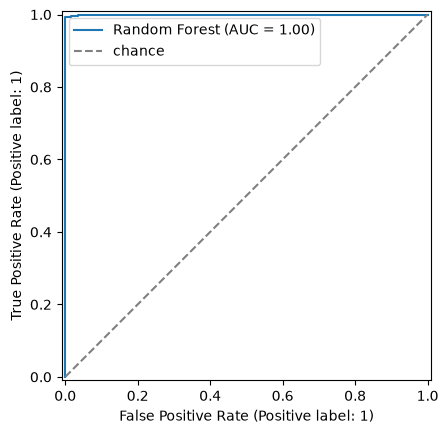

AUC: 0.9998


In [14]:
from sklearn.metrics import RocCurveDisplay

# use predicted probabilities (not hard class labels) so we can sweep the threshold
y_score = clf.predict_proba(X_test)[:, 1]  # P(attack)

RocCurveDisplay.from_predictions(y_test, y_score, name="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="chance")
plt.legend()
plt.show()

from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_score)
print(f"AUC: {auc:.4f}")

## Thought Question

Which evaluation model is more appropriate, and when (i.e., under what circumstances)? When might you care more about looking at the confusion matrix (or model accuracy) vs. the ROC, or the area under the curve?

A confusion matrix is definitely more useful when trying to look at the 